Model Egitimi - LSTM ve GRU

Bu notebook'ta:
1. Preprocessing notebook'unda kaydedilen verileri yukleyecegiz
2. LSTM ve GRU model siniflarini tanimlayacagiz
3. Her iki modeli egitecegiz
4. Egitilmis modelleri ve egitim gecmisini kaydedecegiz


In [1]:
import numpy as np
import torch
import torch.nn as nn
import pickle
import time

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Cihaz: {device}")

PyTorch: 2.12.0+cpu
CUDA: False
Cihaz: cpu


In [2]:
# Tensorleri yukle
tensors = torch.load('../data/tensors.pt', weights_only=True)
x_train = tensors['x_train']
y_train = tensors['y_train']
x_test = tensors['x_test']
y_test = tensors['y_test']

# Metadata yukle
with open('../data/metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

print("Veriler yuklendi")
print(f"  x_train: {x_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  x_test:  {x_test.shape}")
print(f"  y_test:  {y_test.shape}")
print(f"\nMetadata:")
for key, val in metadata.items():
    print(f"  {key}: {val}")

Veriler yuklendi
  x_train: torch.Size([2898, 19, 1])
  y_train: torch.Size([2898, 1])
  x_test:  torch.Size([724, 19, 1])
  y_test:  torch.Size([724, 1])

Metadata:
  lookback: 20
  train_size: 2898
  test_size: 724
  seq_length: 19
  train_dates: ('2012-02-01', '2023-08-08')
  test_dates: ('2023-08-09', '2026-06-29')


In [3]:
input_dim = 1        # Giris boyutu: sadece kapanis fiyati
hidden_dim = 32      # Gizli katman boyutu
num_layers = 2       # RNN katman sayisi
output_dim = 1       # Cikis boyutu: tek deger tahmini
num_epochs = 100     # Egitim dongusu
learning_rate = 0.01 # Ogrenme orani

print("Hiperparametreler:")
print(f"  input_dim:     {input_dim}")
print(f"  hidden_dim:    {hidden_dim}")
print(f"  num_layers:    {num_layers}")
print(f"  output_dim:    {output_dim}")
print(f"  num_epochs:    {num_epochs}")
print(f"  learning_rate: {learning_rate}")

Hiperparametreler:
  input_dim:     1
  hidden_dim:    32
  num_layers:    2
  output_dim:    1
  num_epochs:    100
  learning_rate: 0.01


In [4]:
class LSTM(nn.Module):
    """
    LSTM modeli.

    Yapi:
      - nn.LSTM: Sekanstaki zamansal bagimliliklari ogrenir
      - nn.Linear: Son zaman adiminin ciktisini tek fiyat tahminine donusturur
    """
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # batch_first=True: giris sekli (batch, sekans, ozellik) olur
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)

        # Son zaman adiminin ciktisini tek degere donusturen katman
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Gizli durum (h0) ve hucre durumu (c0) sifirlarla baslatilir
        # Sekil: (katman_sayisi, batch_boyutu, gizli_boyut)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()

        # .detach() ile gradyan grafigini kopariyoruz
        # Her batch icin temiz bir baslangic saglar
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))

        # Sadece son zaman adiminin ciktisini al
        # Cunku bir sonraki gunu tahmin ediyoruz
        out = self.fc(out[:, -1, :])
        return out

print("LSTM sinifi tanimlandi")

LSTM sinifi tanimlandi


In [5]:
class GRU(nn.Module):
    """
    GRU modeli.

    LSTM'e benzer ama daha basit:
      - Cell state yok, sadece hidden state var
      - 2 kapi (LSTM'de 3 kapi)
      - Daha az parametre, daha hizli egitim
    """
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(GRU, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # GRU'da sadece gizli durum (h0) var - hucre durumu yok
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()

        out, (hn) = self.gru(x, (h0.detach()))

        # Son zaman adiminin ciktisi
        out = self.fc(out[:, -1, :])
        return out

print("GRU sinifi tanimlandi")

GRU sinifi tanimlandi


In [6]:
# Parametre sayilarini karsilastir
lstm_temp = LSTM(input_dim, hidden_dim, num_layers, output_dim)
gru_temp = GRU(input_dim, hidden_dim, num_layers, output_dim)

lstm_params = sum(p.numel() for p in lstm_temp.parameters())
gru_params = sum(p.numel() for p in gru_temp.parameters())

print("Parametre karsilastirmasi:")
print(f"  LSTM: {lstm_params:,} parametre")
print(f"  GRU:  {gru_params:,} parametre")
print(f"  Fark: {lstm_params - gru_params:,} ({((lstm_params - gru_params) / gru_params) * 100:.1f}% daha fazla)")
print(f"\nLSTM daha fazla parametreye sahip cunku 3 kapi + cell state kullaniyor.")

del lstm_temp, gru_temp

Parametre karsilastirmasi:
  LSTM: 12,961 parametre
  GRU:  9,729 parametre
  Fark: 3,232 (33.2% daha fazla)

LSTM daha fazla parametreye sahip cunku 3 kapi + cell state kullaniyor.


In [7]:
def train_model(model, x_train, y_train, num_epochs, learning_rate, model_name="Model"):
    """
    Verilen modeli egitir ve egitim gecmisini dondurur.

    Parametreler:
        model         : nn.Module - egitilecek model
        x_train       : Tensor - egitim girisleri
        y_train       : Tensor - egitim hedefleri
        num_epochs    : int - epoch sayisi
        learning_rate : float - ogrenme orani
        model_name    : str - log icin model adi

    Dondurur:
        hist          : list - her epoch'un loss degeri
        training_time : float - toplam egitim suresi (saniye)
    """
    # Kayip fonksiyonu ve optimizer
    criterion = nn.MSELoss(reduction='mean')
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    hist = []
    start_time = time.time()

    print(f"{model_name} egitimi basliyor ({num_epochs} epoch)...")
    print("-" * 45)

    for epoch in range(num_epochs):
        model.train()

        # 1. Ileri yayilim: tahmin uret
        y_pred = model(x_train)

        # 2. Kaybi hesapla
        loss = criterion(y_pred, y_train)
        hist.append(loss.item())

        # Her 10 epoch'ta bir yazdir
        if epoch % 10 == 0 or epoch == num_epochs - 1:
            print(f"  Epoch {epoch:3d}/{num_epochs}  |  MSE: {loss.item():.6f}")

        # 3. Gradyanlari sifirla
        optimizer.zero_grad()

        # 4. Geri yayilim
        loss.backward()

        # 5. Agirliklari guncelle
        optimizer.step()

    training_time = time.time() - start_time
    print("-" * 45)
    print(f"{model_name} egitimi tamamlandi")
    print(f"  Sure: {training_time:.2f} saniye")
    print(f"  Son loss: {hist[-1]:.6f}")

    return hist, training_time

print("train_model fonksiyonu tanimlandi")

train_model fonksiyonu tanimlandi


In [8]:
model_lstm = LSTM(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    output_dim=output_dim
)

hist_lstm, time_lstm = train_model(
    model=model_lstm,
    x_train=x_train,
    y_train=y_train,
    num_epochs=num_epochs,
    learning_rate=learning_rate,
    model_name="LSTM"
)

LSTM egitimi basliyor (100 epoch)...
---------------------------------------------
  Epoch   0/100  |  MSE: 0.462393
  Epoch  10/100  |  MSE: 0.035608
  Epoch  20/100  |  MSE: 0.007997
  Epoch  30/100  |  MSE: 0.005559
  Epoch  40/100  |  MSE: 0.002189
  Epoch  50/100  |  MSE: 0.000977
  Epoch  60/100  |  MSE: 0.000810
  Epoch  70/100  |  MSE: 0.000703
  Epoch  80/100  |  MSE: 0.000652
  Epoch  90/100  |  MSE: 0.000625
  Epoch  99/100  |  MSE: 0.000604
---------------------------------------------
LSTM egitimi tamamlandi
  Sure: 8.01 saniye
  Son loss: 0.000604


In [9]:
model_gru = GRU(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    output_dim=output_dim
)

hist_gru, time_gru = train_model(
    model=model_gru,
    x_train=x_train,
    y_train=y_train,
    num_epochs=num_epochs,
    learning_rate=learning_rate,
    model_name="GRU"
)

GRU egitimi basliyor (100 epoch)...
---------------------------------------------
  Epoch   0/100  |  MSE: 0.387622
  Epoch  10/100  |  MSE: 0.021957
  Epoch  20/100  |  MSE: 0.005191
  Epoch  30/100  |  MSE: 0.001412
  Epoch  40/100  |  MSE: 0.000940
  Epoch  50/100  |  MSE: 0.000628
  Epoch  60/100  |  MSE: 0.000397
  Epoch  70/100  |  MSE: 0.000329
  Epoch  80/100  |  MSE: 0.000305
  Epoch  90/100  |  MSE: 0.000287
  Epoch  99/100  |  MSE: 0.000277
---------------------------------------------
GRU egitimi tamamlandi
  Sure: 12.41 saniye
  Son loss: 0.000277


In [10]:
print("Egitim suresi karsilastirmasi:")
print(f"  LSTM: {time_lstm:.2f} saniye")
print(f"  GRU:  {time_gru:.2f} saniye")
diff = abs(time_lstm - time_gru)
faster = "GRU" if time_gru < time_lstm else "LSTM"
print(f"  {faster} {diff:.2f} saniye daha hizli")

Egitim suresi karsilastirmasi:
  LSTM: 8.01 saniye
  GRU:  12.41 saniye
  LSTM 4.39 saniye daha hizli


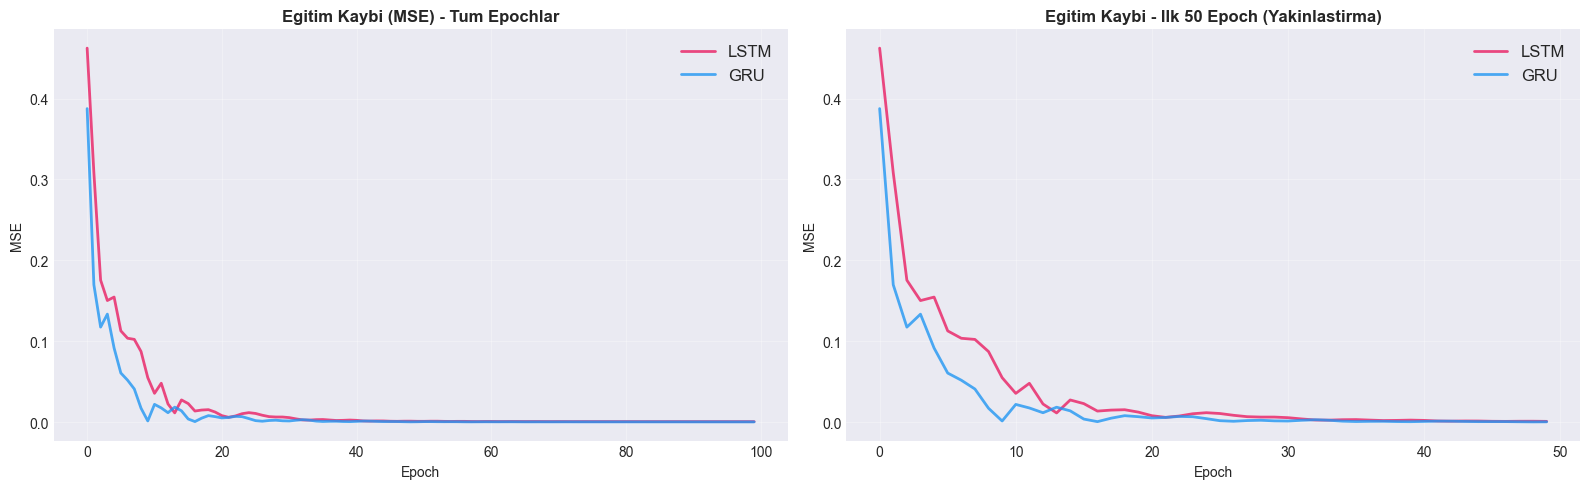

Grafik kaydedildi: results/training_loss.png


In [11]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sol: tum epochlar
axes[0].plot(hist_lstm, color='#E91E63', linewidth=2, label='LSTM', alpha=0.8)
axes[0].plot(hist_gru, color='#2196F3', linewidth=2, label='GRU', alpha=0.8)
axes[0].set_title('Egitim Kaybi (MSE) - Tum Epochlar', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# Sag: ilk 50 epoch (detay)
axes[1].plot(hist_lstm[:50], color='#E91E63', linewidth=2, label='LSTM', alpha=0.8)
axes[1].plot(hist_gru[:50], color='#2196F3', linewidth=2, label='GRU', alpha=0.8)
axes[1].set_title('Egitim Kaybi - Ilk 50 Epoch (Yakinlastirma)', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi: results/training_loss.png")

In [12]:
# Modelleri kaydet
torch.save(model_lstm.state_dict(), '../data/model_lstm.pt')
torch.save(model_gru.state_dict(), '../data/model_gru.pt')
print("Modeller kaydedildi:")
print("  data/model_lstm.pt")
print("  data/model_gru.pt")

# Egitim gecmisini kaydet
training_history = {
    'hist_lstm': hist_lstm,
    'hist_gru': hist_gru,
    'time_lstm': time_lstm,
    'time_gru': time_gru,
    'hyperparams': {
        'input_dim': input_dim,
        'hidden_dim': hidden_dim,
        'num_layers': num_layers,
        'output_dim': output_dim,
        'num_epochs': num_epochs,
        'learning_rate': learning_rate,
    }
}

with open('../data/training_history.pkl', 'wb') as f:
    pickle.dump(training_history, f)
print("\nEgitim gecmisi kaydedildi: data/training_history.pkl")

# Dosya boyutlari
import os
for fname in ['model_lstm.pt', 'model_gru.pt', 'training_history.pkl']:
    fpath = f'../data/{fname}'
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {fname}: {size_kb:.1f} KB")

Modeller kaydedildi:
  data/model_lstm.pt
  data/model_gru.pt

Egitim gecmisi kaydedildi: data/training_history.pkl
  model_lstm.pt: 54.6 KB
  model_gru.pt: 42.0 KB
  training_history.pkl: 2.0 KB
